In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('Dimuon_DoubleMu.csv')

In [3]:
data=data.sample(frac=1)
data.drop(['Run','Event','type1'],axis=1,inplace=True)
#data= data.set_index('Event')
data

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
19484,12.7441,6.6443,5.2544,9.5208,8.4708,0.9664,0.6691,1,G,10.7868,-8.5406,-3.2422,-5.7349,9.1353,-0.5925,-2.7788,-1,23.0592
2571,14.8047,-0.5225,-5.4256,-13.7644,5.4507,-1.6566,-1.6668,-1,G,13.7291,1.1472,4.7173,-12.8416,4.8548,-1.6998,1.3322,1,10.2667
25970,14.7584,7.2515,2.0160,12.6945,7.5266,1.2940,0.2712,1,G,16.4266,10.2568,1.5141,12.7407,10.3680,1.0343,0.1466,-1,2.5589
54994,6.5519,-5.1737,-3.8014,-1.3032,6.4201,-0.2016,-2.5079,1,G,5.4951,3.4121,2.4170,-3.5639,4.1814,-0.7730,0.6163,-1,10.7899
97645,6.8890,-1.6927,-3.2930,5.8084,3.8384,1.2323,-2.0475,1,G,6.3715,2.3824,5.0771,-3.0218,5.6083,-0.5157,1.1321,-1,12.8224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28958,20.6016,10.7976,5.7208,-16.5860,12.2195,-1.1129,0.4872,-1,G,7.9418,-4.0311,-1.8150,6.5968,4.4208,1.1904,-2.7185,1,25.5715
35913,8.2271,4.4348,-1.2660,6.8121,4.6119,1.1820,-0.2781,1,G,10.8070,3.3729,0.0481,10.2665,3.3732,1.8321,0.0143,-1,2.8594
20093,11.1910,1.8921,-3.6769,10.3985,4.1352,1.6527,-1.0956,-1,G,5.7672,-1.6234,4.9410,-2.4901,5.2009,-0.4621,1.8882,1,14.9455
69329,99.0505,18.7102,40.4239,88.4693,44.5439,1.4374,1.1373,-1,G,30.0265,-29.1037,-7.2584,-1.3670,29.9952,-0.0456,-2.8972,1,88.6908


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 19484 to 15332
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   E1      100000 non-null  float64
 1   px1     100000 non-null  float64
 2   py1     100000 non-null  float64
 3   pz1     100000 non-null  float64
 4   pt1     100000 non-null  float64
 5   eta1    100000 non-null  float64
 6   phi1    100000 non-null  float64
 7   Q1      100000 non-null  int64  
 8   type2   100000 non-null  object 
 9   E2      100000 non-null  float64
 10  px2     100000 non-null  float64
 11  py2     100000 non-null  float64
 12  pz2     100000 non-null  float64
 13  pt2     100000 non-null  float64
 14  eta2    100000 non-null  float64
 15  phi2    100000 non-null  float64
 16  Q2      100000 non-null  int64  
 17  M       100000 non-null  float64
dtypes: float64(15), int64(2), object(1)
memory usage: 14.5+ MB


In [5]:
data.isnull()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
19484,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2571,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
25970,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
54994,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
97645,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28958,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
35913,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
20093,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69329,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
type2    0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64

<Axes: >

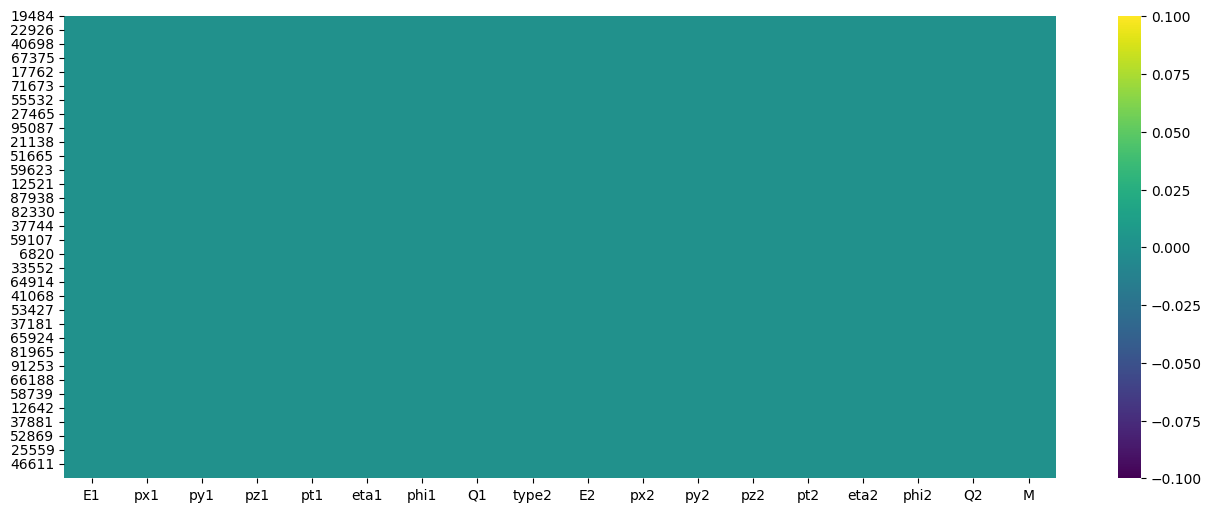

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
type2    0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64

In [10]:
data.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
19484,12.7441,6.6443,5.2544,9.5208,8.4708,0.9664,0.6691,1,G,10.7868,-8.5406,-3.2422,-5.7349,9.1353,-0.5925,-2.7788,-1,23.0592
2571,14.8047,-0.5225,-5.4256,-13.7644,5.4507,-1.6566,-1.6668,-1,G,13.7291,1.1472,4.7173,-12.8416,4.8548,-1.6998,1.3322,1,10.2667
25970,14.7584,7.2515,2.0160,12.6945,7.5266,1.2940,0.2712,1,G,16.4266,10.2568,1.5141,12.7407,10.3680,1.0343,0.1466,-1,2.5589
54994,6.5519,-5.1737,-3.8014,-1.3032,6.4201,-0.2016,-2.5079,1,G,5.4951,3.4121,2.4170,-3.5639,4.1814,-0.7730,0.6163,-1,10.7899
97645,6.8890,-1.6927,-3.2930,5.8084,3.8384,1.2323,-2.0475,1,G,6.3715,2.3824,5.0771,-3.0218,5.6083,-0.5157,1.1321,-1,12.8224


In [11]:
type2=pd.get_dummies(data['type2'],drop_first=True,dtype=float)
type2

,T
19484,0.0
2571,0.0
25970,0.0
54994,0.0
97645,0.0
...,...
28958,0.0
35913,0.0
20093,0.0
69329,0.0


In [12]:
data=pd.concat([data,type2],axis=1)
data.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,T
19484,12.7441,6.6443,5.2544,9.5208,8.4708,0.9664,0.6691,1,G,10.7868,-8.5406,-3.2422,-5.7349,9.1353,-0.5925,-2.7788,-1,23.0592,0.0
2571,14.8047,-0.5225,-5.4256,-13.7644,5.4507,-1.6566,-1.6668,-1,G,13.7291,1.1472,4.7173,-12.8416,4.8548,-1.6998,1.3322,1,10.2667,0.0
25970,14.7584,7.2515,2.0160,12.6945,7.5266,1.2940,0.2712,1,G,16.4266,10.2568,1.5141,12.7407,10.3680,1.0343,0.1466,-1,2.5589,0.0
54994,6.5519,-5.1737,-3.8014,-1.3032,6.4201,-0.2016,-2.5079,1,G,5.4951,3.4121,2.4170,-3.5639,4.1814,-0.7730,0.6163,-1,10.7899,0.0
97645,6.8890,-1.6927,-3.2930,5.8084,3.8384,1.2323,-2.0475,1,G,6.3715,2.3824,5.0771,-3.0218,5.6083,-0.5157,1.1321,-1,12.8224,0.0


In [13]:
data.drop(['type2'],axis=1,inplace=True)
data.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,T
19484,12.7441,6.6443,5.2544,9.5208,8.4708,0.9664,0.6691,1,10.7868,-8.5406,-3.2422,-5.7349,9.1353,-0.5925,-2.7788,-1,23.0592,0.0
2571,14.8047,-0.5225,-5.4256,-13.7644,5.4507,-1.6566,-1.6668,-1,13.7291,1.1472,4.7173,-12.8416,4.8548,-1.6998,1.3322,1,10.2667,0.0
25970,14.7584,7.2515,2.0160,12.6945,7.5266,1.2940,0.2712,1,16.4266,10.2568,1.5141,12.7407,10.3680,1.0343,0.1466,-1,2.5589,0.0
54994,6.5519,-5.1737,-3.8014,-1.3032,6.4201,-0.2016,-2.5079,1,5.4951,3.4121,2.4170,-3.5639,4.1814,-0.7730,0.6163,-1,10.7899,0.0
97645,6.8890,-1.6927,-3.2930,5.8084,3.8384,1.2323,-2.0475,1,6.3715,2.3824,5.0771,-3.0218,5.6083,-0.5157,1.1321,-1,12.8224,0.0


In [14]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 19484 to 15332
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   E1      100000 non-null  float64
 1   px1     100000 non-null  float64
 2   py1     100000 non-null  float64
 3   pz1     100000 non-null  float64
 4   pt1     100000 non-null  float64
 5   eta1    100000 non-null  float64
 6   phi1    100000 non-null  float64
 7   Q1      100000 non-null  int64  
 8   E2      100000 non-null  float64
 9   px2     100000 non-null  float64
 10  py2     100000 non-null  float64
 11  pz2     100000 non-null  float64
 12  pt2     100000 non-null  float64
 13  eta2    100000 non-null  float64
 14  phi2    100000 non-null  float64
 15  Q2      100000 non-null  int64  
 16  M       100000 non-null  float64
 17  T       100000 non-null  float64
dtypes: float64(16), int64(2)
memory usage: 14.5 MB


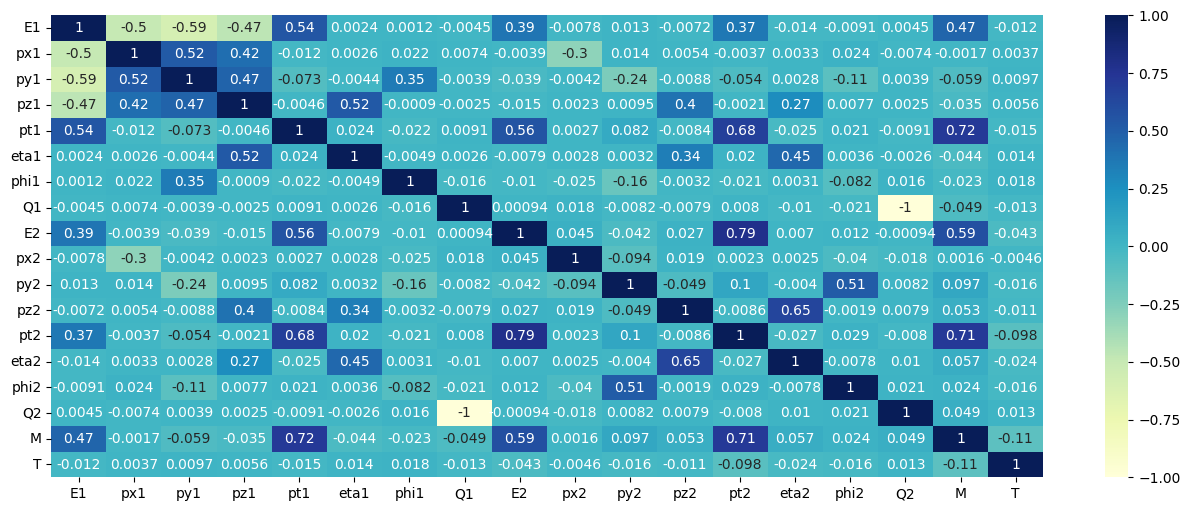

In [15]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [16]:
corrM[corrM['E2']>0.1][['E2']]

,E2
E1,0.387911
pt1,0.559408
E2,1.000000
pt2,0.786694
M,0.587391


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x=data.drop(['E2'],axis=1)
x=data[['E1','pt1','pt2','M']]

x.head()

,E1,pt1,pt2,M
19484,12.7441,8.4708,9.1353,23.0592
2571,14.8047,5.4507,4.8548,10.2667
25970,14.7584,7.5266,10.3680,2.5589
54994,6.5519,6.4201,4.1814,10.7899
97645,6.8890,3.8384,5.6083,12.8224


In [19]:
y=data['E2']
y

19484    10.7868
2571     13.7291
25970    16.4266
54994     5.4951
97645     6.3715
          ...   
28958     7.9418
35913    10.8070
20093     5.7672
69329    30.0265
15332     8.6280
Name: E2, Length: 100000, dtype: float64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.005, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model=LinearRegression()

In [23]:
model.fit(X_train,y_train)

LinearRegression()

In [24]:
pred=model.predict(X_test)
pred

array([ 5.18287065,  9.88092409, 21.00102755, 36.08313188,  7.09076625,
       10.35630106,  9.34028692,  8.09989285, 15.7890658 , 18.40704614,
        8.51408473, 17.94432404,  7.24240574,  2.76549604, 12.5684021 ,
       10.70911173, 10.14612713, 17.53290225,  6.43714943, 11.98301673,
        8.58380207, 46.04237499, 13.16401089,  9.73591786,  9.79657489,
       32.95587825, 21.13862046, 10.24252486,  7.79490801,  8.24100227,
       15.5929627 , 14.18750675,  6.49304467,  9.89636284,  7.51706165,
        7.2797563 ,  9.57117676,  2.80442469,  8.60014356, 15.13028949,
        7.98794306, 17.07870322, 26.2159078 ,  6.52473615, 10.43698699,
        8.29519255,  6.00985551, 10.49406581, 13.18198024,  5.90980003,
        6.8313716 , 15.06630699, 14.5495819 , 25.85999364,  7.49581173,
       13.01058281,  3.67769585, 16.7480024 , 26.28608018, 11.60550315,
       41.48440946, 45.80557957, 30.49135079,  8.3867162 , 21.0179913 ,
        9.57702534, 12.90399605, 17.58799768, 55.10043375, 13.17

In [25]:
y_test

35062     7.0389
59970    21.9502
10811    29.8813
45332    26.3196
4916     14.7045
          ...   
98493    14.0960
14828     9.4838
38216     4.5835
94734     7.2983
18534     4.8322
Name: E2, Length: 500, dtype: float64

In [26]:
X_test

,E1,pt1,pt2,M
35062,7.6233,3.8866,3.1631,6.6767
59970,21.1180,6.8178,6.2105,13.0470
10811,20.3597,8.5400,14.8598,3.0469
45332,19.5697,14.5600,26.2385,41.4829
4916,34.1951,8.0326,3.6595,0.5431
...,...,...,...,...
98493,10.9733,4.1226,6.6617,24.7106
14828,7.8978,6.0777,6.8391,0.6641
38216,8.8611,8.2895,1.2855,9.8539
94734,7.1687,7.1145,5.5391,13.8291


In [27]:
model.score(X_test, y_test)

0.6833975889001478

In [28]:
pred

array([ 5.18287065,  9.88092409, 21.00102755, 36.08313188,  7.09076625,
       10.35630106,  9.34028692,  8.09989285, 15.7890658 , 18.40704614,
        8.51408473, 17.94432404,  7.24240574,  2.76549604, 12.5684021 ,
       10.70911173, 10.14612713, 17.53290225,  6.43714943, 11.98301673,
        8.58380207, 46.04237499, 13.16401089,  9.73591786,  9.79657489,
       32.95587825, 21.13862046, 10.24252486,  7.79490801,  8.24100227,
       15.5929627 , 14.18750675,  6.49304467,  9.89636284,  7.51706165,
        7.2797563 ,  9.57117676,  2.80442469,  8.60014356, 15.13028949,
        7.98794306, 17.07870322, 26.2159078 ,  6.52473615, 10.43698699,
        8.29519255,  6.00985551, 10.49406581, 13.18198024,  5.90980003,
        6.8313716 , 15.06630699, 14.5495819 , 25.85999364,  7.49581173,
       13.01058281,  3.67769585, 16.7480024 , 26.28608018, 11.60550315,
       41.48440946, 45.80557957, 30.49135079,  8.3867162 , 21.0179913 ,
        9.57702534, 12.90399605, 17.58799768, 55.10043375, 13.17

In [29]:
y_test

35062     7.0389
59970    21.9502
10811    29.8813
45332    26.3196
4916     14.7045
          ...   
98493    14.0960
14828     9.4838
38216     4.5835
94734     7.2983
18534     4.8322
Name: E2, Length: 500, dtype: float64

In [30]:
indexes = X_test.index.values
len(indexes)

500

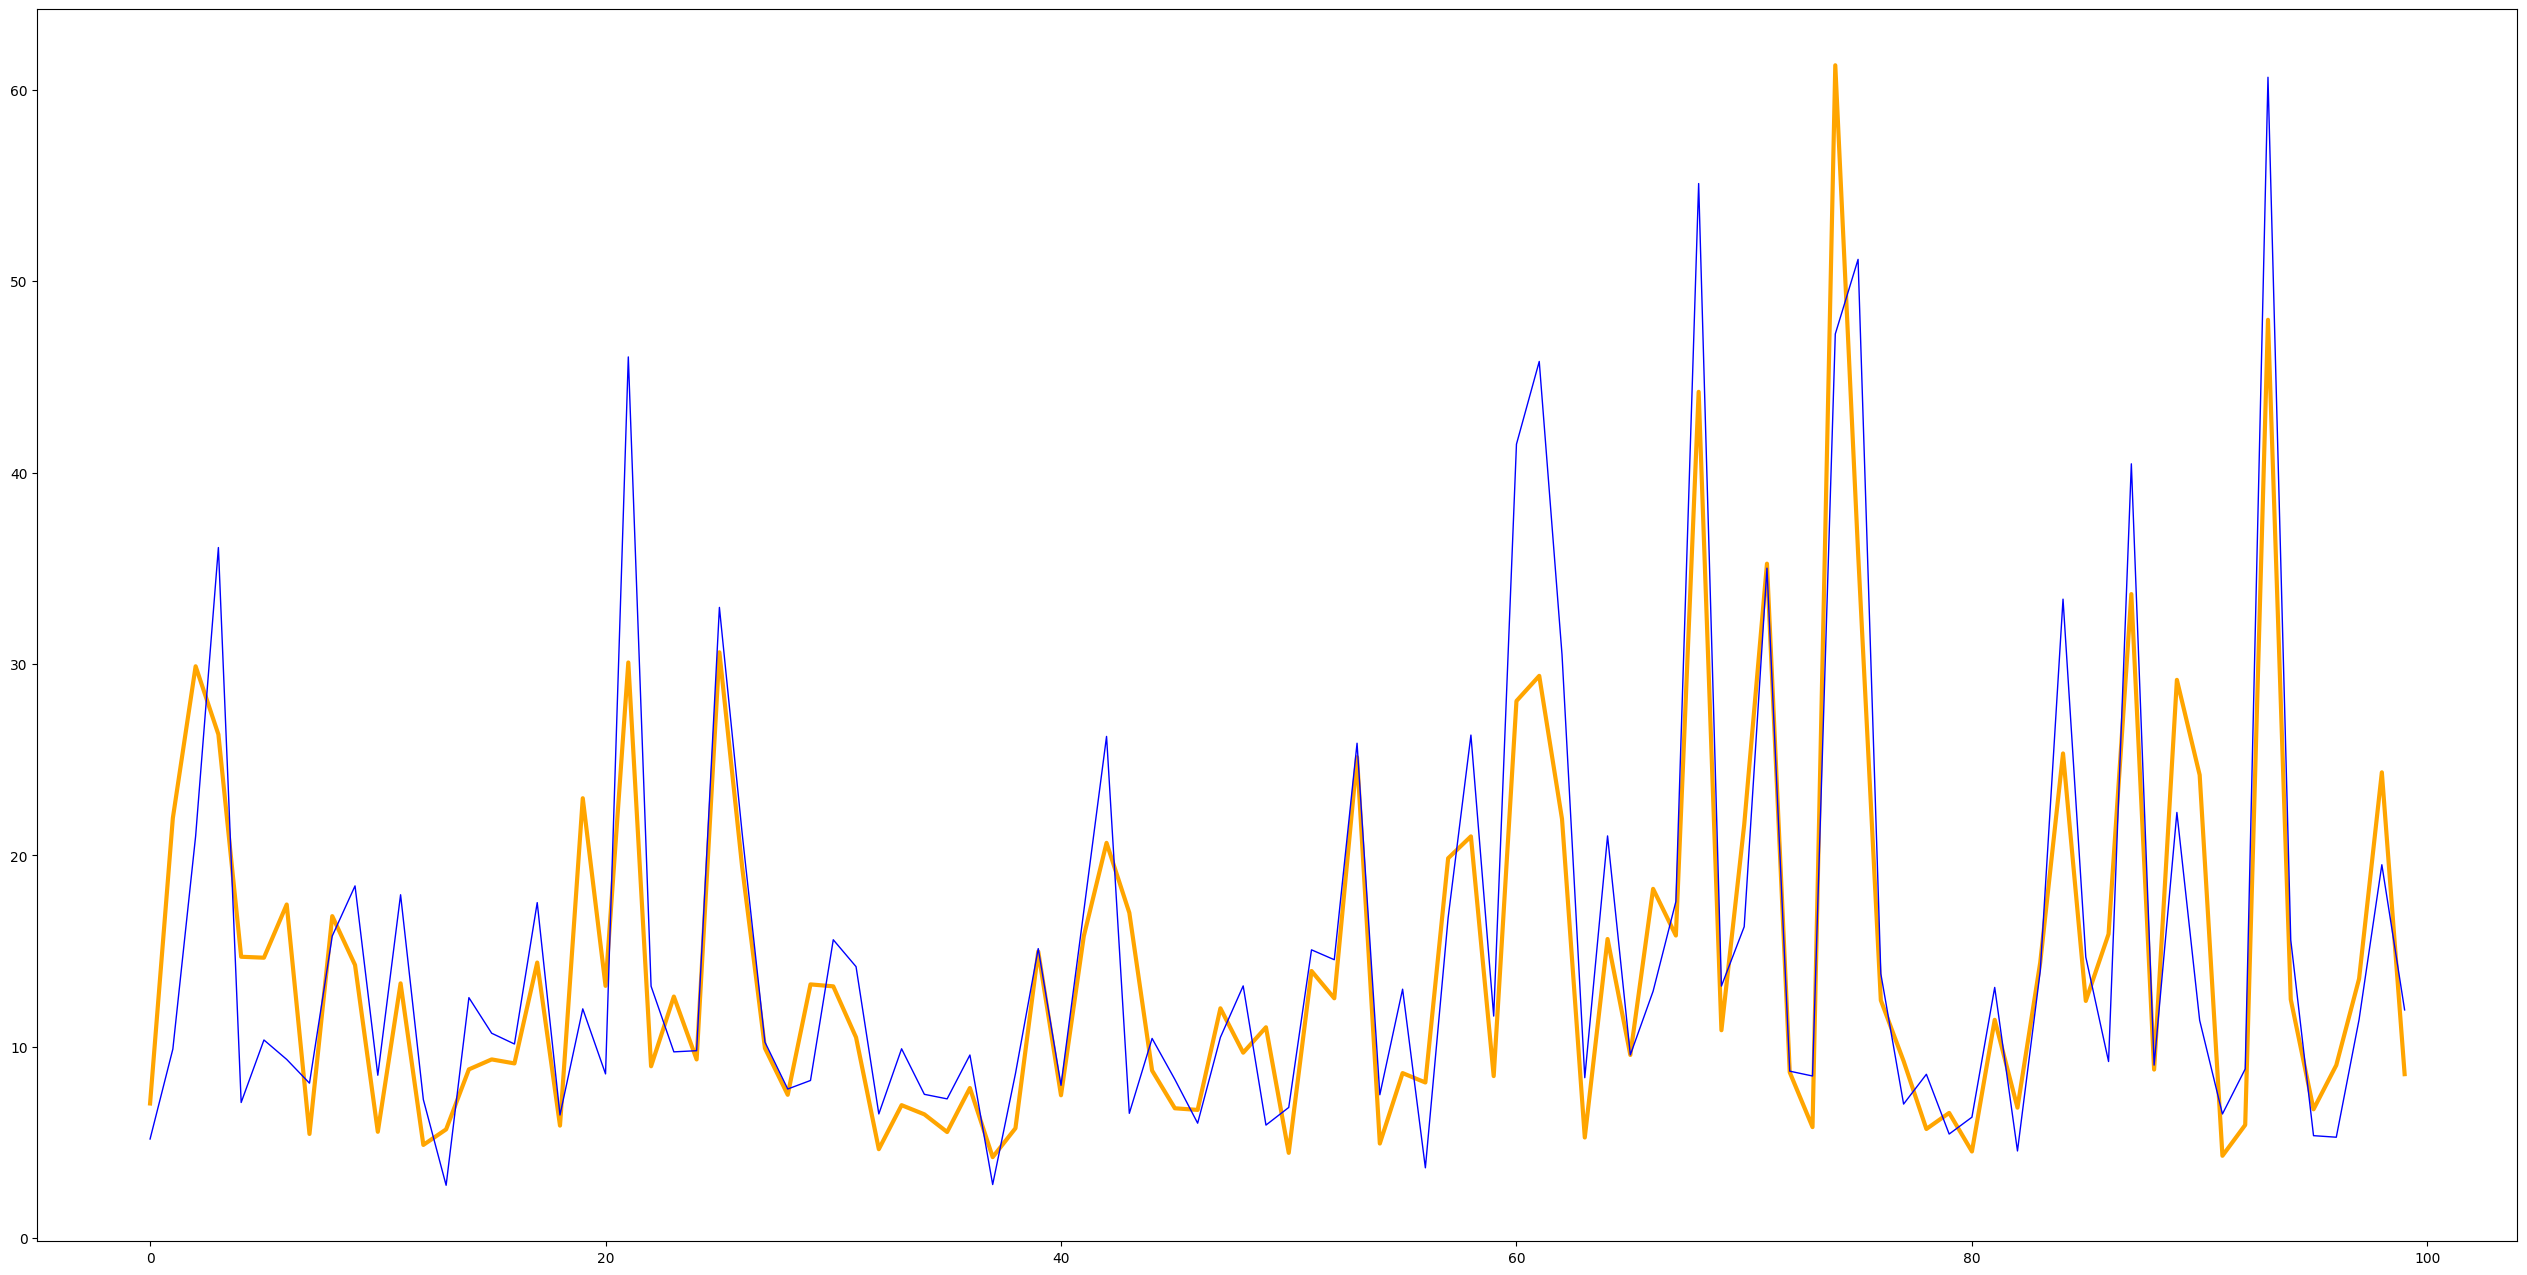

In [33]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[0:100],y_test[0:100], color="orange", linewidth=3)
plt.plot(range(0,len(indexes))[0:100],pred[0:100], color="blue", linewidth=1)
plt.show()